In [79]:
from __future__ import annotations

import yaml
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

idx = pd.IndexSlice

In [80]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

# inplace update: give these gas-ish techs a more diverse palette (not all brown)
tech_colors.update({
    "SMR CC":                        "#1f77b4",  # blue
    "heat100-200 industry gas":      "#ff7f0e",  # orange
    "heat<100 industry gas":         "#2ca02c",  # green
    "Combined-Cycle Gas":            "#d62728",  # red
    "Open-Cycle Gas":                "#9467bd",  # purple
    "heat200-500 industry gas":      "#17becf",  # cyan
    "H2 electrolysis":               "#e377c2",  # pink
    "urban central gas boiler":      "#7f7f7f",  # grey
    "urban central gas CHP":         "#bcbd22",  # olive
    "rural gas boiler":              "#8c564b",  # brown (keep one brown, but not all)
    "urban decentral gas boiler":    "#aec7e8",  # light blue
    "urban decentral biomass boiler":"#92648c",  # purple
    "rural biomass boiler":          "#94312c",  # purple
    "heat>500 industry gas":         "#98df8a",  # light green
    "gas DRI":                       "#000000",  # black

    # Additions reflecting explicit categories from the picture/code:
    # (assigning suitable colors, some re-using for semantic consistency)
    ">500C industry heat and feedstock": "#17becf",   # tan/grayish
    "<500C industry heat":               "#98df8a",   # brown (matches rural gas boiler)
    "biomethane":                        "gold",   # teal
    "hydrogen heating":               "magenta",   # pink (matches SMR)
    "building heat":                  "#94312c",   # grey (matches urban central gas boiler)
    "electricity":                  "#d62728",   # red (matches Combined-Cycle Gas)
})
tech_colors['residential gas boiler'] = tech_colors['urban decentral gas boiler']
tech_colors['gas turbine'] = tech_colors['Open-Cycle Gas']
tech_colors['wind'] = tech_colors['Onshore Wind']
tech_colors['solar'] = tech_colors['solar-hsat']
tech_colors['biomass buildings'] = tech_colors['urban decentral biomass boiler']
tech_colors['biomass industry'] = tech_colors['heat200-500 industry solid biomass']
tech_colors['building heat pump'] = tech_colors['ground heat pump']
tech_colors['building electric heating'] = tech_colors['ground heat pump']
tech_colors['industrial heat pump'] = tech_colors['heat<100 industry industrial heat pump medium temperature']


In [81]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_4000.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_4000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [82]:
mode = '168'

nb = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'nodal_energy_balance.csv', index_col=list(range(4)), header=list(range(5))
).loc[:,idx[:,:,:,'free']]
nb.columns = nb.columns.get_level_values(-1).astype(int)

In [83]:
bal = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'energy_balance.csv', index_col=list(range(3)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
bal.columns = bal.columns.get_level_values(-1).astype(int)

In [84]:
mp = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'prices.csv', index_col=list(range(1)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
mp.columns = mp.columns.get_level_values(-1).astype(int)

commodity_prices = mp.loc[['gas', 'low voltage', 'urban decentral heat', 'heat<100 industry']]
# gas_price.index = gas_price.index.get_level_values(-1)
commodity_prices.head()

commidity_nice_names = {
    'gas': 'gas',
    'low voltage': 'electricity',
    'urban decentral heat': 'residential heating',
    'heat<100 industry': 'low-temperature\nindustry heat',
}
commidity_colors = {
    'gas': tech_colors['gas'],
    'low voltage': tech_colors['AC'],
    'urban decentral heat': tech_colors['urban decentral gas boiler'],
    'heat<100 industry': tech_colors['heat<100 industry'],
}

In [85]:
idx = pd.IndexSlice
gas = bal.loc[idx[:, :, 'gas']]

gascon = gas.loc[gas.sum(axis=1) < 0].abs().mul(1e-6)
gascon.index = gascon.index.droplevel(0)
gascon = gascon.sort_values(gascon.columns[-1])

gasgen = gas.loc[gas.sum(axis=1) > 0].mul(1e-6)
gasgen.index = gasgen.index.droplevel(0)

In [86]:
ref = gascon.iloc[:,-1]
dis = gascon.iloc[:,:-1]

threshold_share = 0.5
gasuse_baseline = mp.columns[-1] # TWh

displaced = dis.sub(ref, axis=0).abs()

df = pd.DataFrame(index=displaced.index, columns=['phase_out_prices', 'phase_out_volume'])

for carrier in displaced.index:

    ss = displaced.loc[carrier]
    ss = ss[ss > threshold_share * ss.max()]

    if not len(ss):
        continue

    df.loc[carrier, 'phase_out_prices'] = mp.loc['gas', ss.index[-1]]
    df.loc[carrier, 'phase_out_volume'] = gasuse_baseline - ss.index[-1]

df.sort_values(by='phase_out_prices', ascending=True, inplace=True)
df.dropna(inplace=True)

ignored = [
    'gas for industry CC',
    'gas for industry',
    ]

df.drop(ignored, inplace=True)

df['gas_consumption'] = gasuse_baseline - df['phase_out_volume']
xlim_lower = 1000
xlim_upper = 4000

##### energy balances

In [87]:
eb = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'energy_balance.csv', header=list(range(5)), index_col=[0,1,2]
)
eb.columns = eb.columns.get_level_values(-1).astype(int)
prices = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'prices.csv', header=list(range(5)), index_col=[0]
)
prices.columns = prices.columns.get_level_values(-1).astype(int)

In [88]:
gas_techs_by_bus = {
    "heat<100 industry": ["heat<100 industry gas"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas", "urban central gas CHP"],
    "rural heat": ["rural gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
    "Hydrogen Storage": ["SMR"],
    "heat>500 industry": ["heat>500 industry gas"],
}

nice_names = {
    "heat<100 industry": "Industry Heat <100°C",
    "heat100-200 industry": "Industry Heat 100-200°C",
    "heat200-500 industry": "Industry Heat 200-500°C",
    "AC": "Electricity",
    "rural heat": "Rural Heating",
    "urban central heat": "District Heating",
    "urban decentral heat": "Urban Decentral Heating",
    "Hydrogen Storage": "Hydrogen",
    "heat>500 industry": "Industry Heat >500°C",
}

In [89]:
costs = pd.read_csv(
    Path.cwd().parent / 'results' / f'csvs_{mode}_latest' / 'costs.csv', index_col=list(range(3)), header=list(range(5))
).sum().mul(1e-9)
costs.index = costs.index.get_level_values(-1)
# Interpolate value for 1750 instead of dropping it
if '1750' in costs.index:
    i = costs.index.get_loc('1750')
    if i > 0 and i < len(costs) - 1:
        prev_val = costs.iloc[i - 1]
        next_val = costs.iloc[i + 1]
        costs.iloc[i] = (prev_val + next_val) / 2
costs.name = 'System Cost [B€]'
costs.index.name = 'Gas Consumption [TWh/a]'

In [90]:
items = [
    # "heat>500 industry gas CC",
    "gas for industry",
    "heat>500 industry gas",
    "heat200-500 industry gas",
    # "gas for industry CC",
    # "Open-Cycle Gas",
    # "Combined-Cycle Gas",
    "gas turbine",
    "residential gas boiler",
    "urban central gas CHP",
    # "SMR CC",
    "SMR",
    "heat<100 industry gas",
    "heat100-200 industry gas",
    "biogas to gas",
]

In [91]:
gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

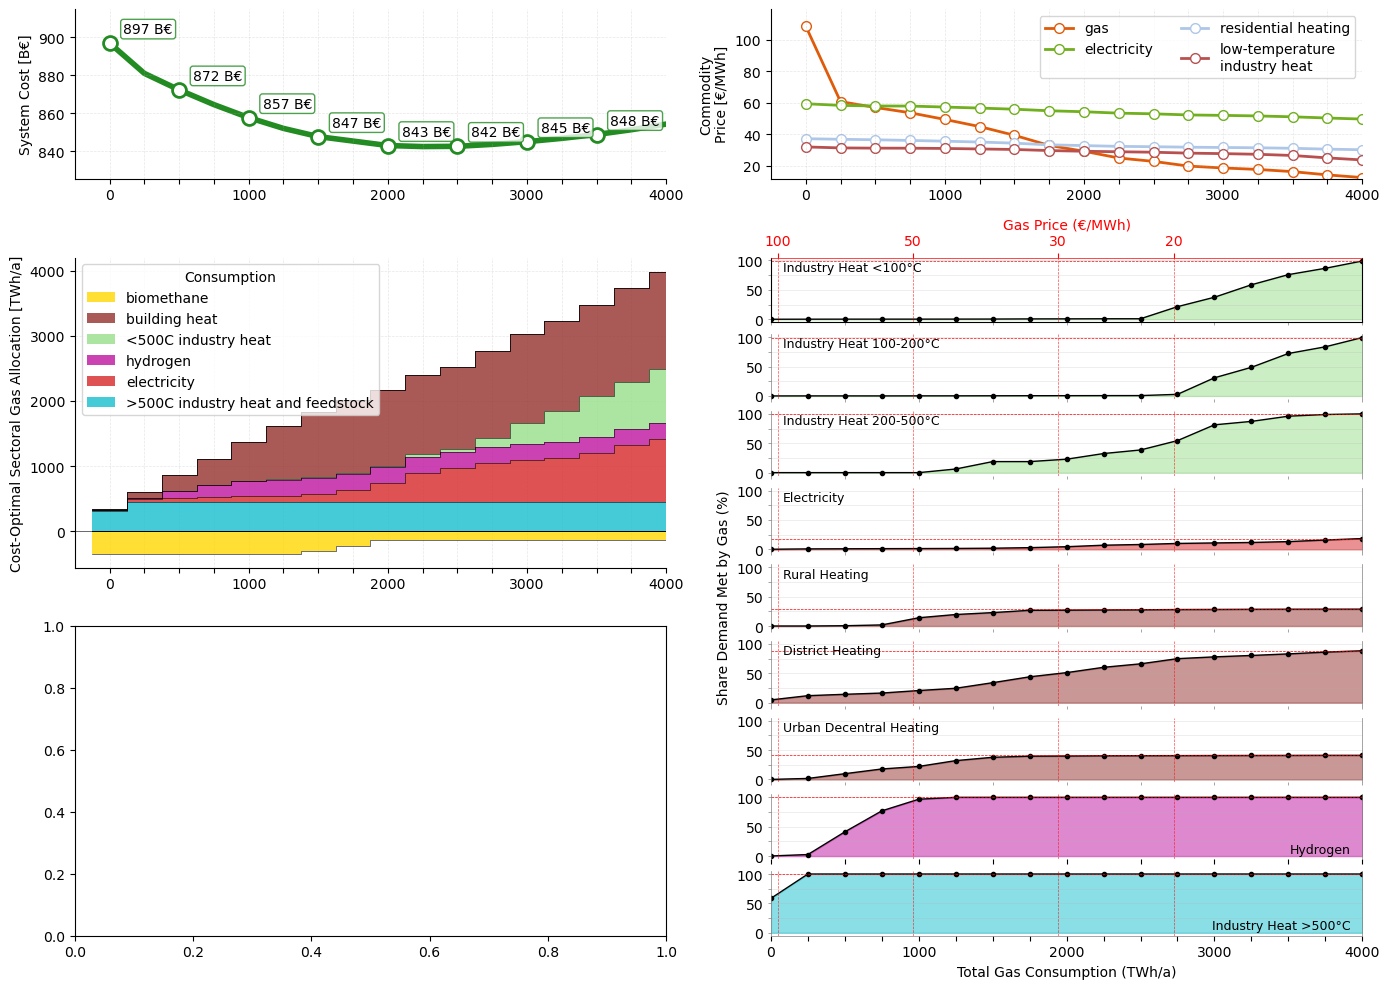

was ist mit rural air heat pumps!?! Check data


In [ ]:

carrier_mapping = {
    'gas for industry': '>500C industry heat and feedstock',
    'heat>500 industry gas': '>500C industry heat and feedstock',
    'heat200-500 industry gas': '<500C industry heat',
    'heat100-200 industry gas': '<500C industry heat',
    'heat<100 industry gas': '<500C industry heat',
    'biogas to gas': 'biomethane',
    'SMR': 'hydrogen',
    'urban decentral gas boiler': 'building heat',
    'urban central gas boiler': 'building heat',
    'urban central gas CHP': 'building heat',
    'rural gas boiler': 'building heat',
    'Open-Cycle Gas': 'electricity',
    'Combined-Cycle Gas': 'electricity',
}

color_mapper = {
    'heat<100 industry': '<500C industry heat',
    'heat100-200 industry': '<500C industry heat',
    'heat200-500 industry': '<500C industry heat',
    'heat>500 industry': '>500C industry heat and feedstock',
    'AC': 'electricity',
    'rural heat': 'building heat',
    'urban central heat': 'building heat',
    'urban decentral heat': 'building heat',
    'Hydrogen Storage': 'hydrogen',
}

items = [
    '>500C industry heat and feedstock',
    'electricity',
    'hydrogen',
    '<500C industry heat',
    'building heat',
    'biomethane',
]

gb = gb.groupby(carrier_mapping).sum()

line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8
}

fig = plt.figure(figsize=(14, 10))
outer = fig.add_gridspec(2, 2, height_ratios=[1, 4], width_ratios=[1, 1])

# Top row: two small axes
ax_top_left  = fig.add_subplot(outer[0, 0])
ax_top_right = fig.add_subplot(outer[0, 1])

# Bottom-left: split into 2 equal axes
gs_left = outer[1, 0].subgridspec(2, 1)
ax_old_0 = fig.add_subplot(gs_left[0])
ax_old_1 = fig.add_subplot(gs_left[1])

# Bottom-right: split into 7 equal axes
gs_right = outer[1, 1].subgridspec(9, 1)
ax_right = [fig.add_subplot(gs_right[i]) for i in range(9)]

ax_old_0.axhline(0, **line_kwargs)

bottoms = pd.Series(0, index=gb.columns, dtype=float)
ceilings = pd.Series(0, index=gb.columns, dtype=float)
width = 1

for i, carrier in enumerate(items):
    row = gb.loc[carrier]
    for j, con in enumerate(row.index):
        value = row.loc[con] * (-1)

        if value < 0:
            ax_old_0.bar(
                j + width/2,
                value,
                bottom=ceilings.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )
            ceilings.loc[con] += value
        else:
            ax_old_0.bar(
                j + width/2,
                value,
                bottom=bottoms.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )
            bottoms.loc[con] += value

    ax_old_0.step(
        np.arange(len(bottoms) + 1),
        np.append(bottoms.values, bottoms.values[-1]),
        where='post',
        **line_kwargs
    )
    ax_old_0.step(
        np.arange(len(bottoms) + 1),
        np.append(ceilings.values, ceilings.values[-1]),
        where='post',
        **line_kwargs
    )

ax_old_0.set_xlim(-width/2, len(bottoms) - width/2)
ax_old_0.spines['right'].set_visible(False)
ax_old_0.spines['top'].set_visible(False)
ax_old_0.grid(linestyle='--', alpha=0.3, linewidth=0.5)
ax_old_0.set_axisbelow(True)

ax_old_0.set_xticks(np.arange(len(bottoms)) + width/2)
ax_old_0.set_xticklabels(
    [label if i % 4 == 0 else '' for i, label in enumerate(bottoms.index)],
    rotation=0
)

# Add legend on the right side
handles = []
labels = []
for carrier in items[::-1]:
    if carrier == 'biogas to gas':
        continue
    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)

ax_old_0.legend(handles, labels, loc='upper left', frameon=True, ncol=1, title='Consumption')

ax_old_0.set_xlabel('')
ax_old_0.set_ylabel('Cost-Optimal Sectoral Gas Allocation [TWh/a]')
ax_old_0.spines['top'].set_visible(False)

# Plot gas price on ax_top_left
y1_min, y1_max = ax_top_left.get_ylim()
if y1_min < 0 < y1_max:
    zero_fraction = -y1_min / (y1_max - y1_min)
else:
    zero_fraction = 0  # If y=0 is not in range, default to bottom

commidity_price_min = commodity_prices.min().min()
commidity_price_max = commodity_prices.max().max()
y2_max = commidity_price_max * 1.1
y2_min = commidity_price_min * 0.95

comm_handles = []
comm_labels = []

for name, row in commodity_prices.iterrows():
    x = np.arange(len(row)) + width/2

    line, = ax_top_right.plot(
        x,
        row.values,
        color=commidity_colors[name],
        linewidth=2,
        zorder=0,
        marker='o',
        markersize=7,
        markerfacecolor='white',
        markeredgecolor=commidity_colors[name],
        markeredgewidth=1,
        label=None,
    )

    comm_handles.append(line)
    comm_labels.append(commidity_nice_names[name])

    ax_top_right.set_xlim(0, len(bottoms))
    ax_top_right.set_ylim(y2_min, y2_max)
    ax_top_right.set_ylabel('Commodity\nPrice [€/MWh]', color='k')
    ax_top_right.tick_params(axis='y', labelcolor='k')

ax_top_right.legend(comm_handles, comm_labels, loc='upper right', frameon=True, ncol=2)

cost_color = 'forestgreen'

x_cost = np.arange(len(costs)) + width/2
ax_top_left.plot(
    x_cost,
    costs.values,
    color=cost_color,
    linewidth=4,
    zorder=0
)
ax_top_left.set_xlim(0, len(bottoms))
costs_min = costs.min()
costs_max = costs.max()
y3_max = costs_max * 1.02
y3_min = costs_min * 0.98
ax_top_left.set_ylim(y3_min, y3_max)
ax_top_left.set_ylabel('System Cost [B€]', color='k')
ax_top_left.tick_params(axis='y', labelcolor='k')

for i in range(0, len(x_cost) - 2, 2):
    xy = (x_cost[i], costs.values[i])
    ax_top_left.annotate(
        f"{int(costs.values[i])} B€",
        xy=xy,
        xytext=(10, 5),
        textcoords="offset points",
        ha='left', va='bottom',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=cost_color, lw=1, alpha=0.8),
        zorder=20
    )
    ax_top_left.plot(
        x_cost[i],
        costs.values[i],
        marker='o',
        color=cost_color,
        markersize=10,
        markerfacecolor='white',
        markeredgecolor=cost_color,
        markeredgewidth=2,
        zorder=15
    )


for ax in [ax_top_left, ax_top_right]:
    ax.set_xlim(ax_old_0.get_xlim())
    ax.set_xticks(ax_old_0.get_xticks())
    ax.set_xticklabels(ax_old_0.get_xticklabels())
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3, linewidth=0.5)

target_bus_carriers = {
    "Hydrogen Storage": ["SMR"],
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas"],
    "gas": ["Sabatier"],
    "biogas": ["biogas to gas"],
    "gas for industry": ["gas for industry", "gas for industry CC"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "heat<100 industry": ["heat<100 industry gas"],
    "heat>500 industry": ["heat>500 industry gas"],
    "rural heat": ["rural gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
}

# for sign, ax in zip([1, 1], [ax_old_0, ax_old_1]):
#     ax.set_yticks([sign * 500 * i for i in range(0, 10)])
#     ax.set_yticklabels([f'{sign * 500 * i}' for i in range(0, 10)])


# ====================================================================    RIGHT AX

idx = pd.IndexSlice

middle_ax_index = len(gas_techs_by_bus) // 2

# Get gas prices for interpolation
gas_prices = prices.loc['gas']

# Interpolate to find x-values where price is 20, 50, and 100
price_thresholds = [20, 30, 50, 100]
x_at_price = {}

for price_threshold in price_thresholds:
    x_at_price[price_threshold] = np.interp(price_threshold, gas_prices.values[::-1], gas_prices.index[::-1])

for i, (bc, techs) in enumerate(gas_techs_by_bus.items()):
    ax = ax_right[i] if len(gas_techs_by_bus) > 1 else ax_right
    
    # Get data for this bus carrier
    ss = eb.loc[idx[:, :, bc], :]
    
    # Calculate total inflow (sum of all positive values)
    total_inflow = ss[ss > 0].sum(axis=0)
    
    # calculate gas tech contribution (sum of specified gas techs)
    gas_contribution = ss.loc[idx[:, techs, :], :].sum(axis=0)
    
    # calculate percentage
    gas_percentage = (gas_contribution / total_inflow * 100).fillna(0)
    # Plot with thin line and small black markers
    x_values = prices.columns
    gas_percentage.index = x_values
    
    ax.plot(x_values, gas_percentage.values, linewidth=1, marker='o', markersize=3, color='black', markerfacecolor='black')
    
    # Add yellow-golden fill between
    ax.fill_between(x_values, np.zeros(len(x_values)), gas_percentage.values, color=tech_colors[color_mapper[bc]], alpha=0.5)
    
    # Add red vertical lines at price thresholds
    for price_threshold in price_thresholds:
        ax.axvline(x_at_price[price_threshold], color='r', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Add bus carrier name as text
    if i >= len(gas_techs_by_bus) - 2:
        ax.text(0.98, 0.05, nice_names[bc], transform=ax.transAxes, fontsize=9, 
                verticalalignment='bottom', horizontalalignment='right')
    else:
        ax.text(0.02, 0.95, nice_names[bc], transform=ax.transAxes, fontsize=9, 
                verticalalignment='top', horizontalalignment='left')
    
    # Set ylabel only for middle axis
    if i == middle_ax_index:
        ax.set_ylabel('Share Demand Met by Gas (%)')
    else:
        ax.set_ylabel('')
    
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3, linewidth=0.5, axis='y')
    
    # Make spines grey to minimize weight
    for spine in ax.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(0.5)

    ax.set_xticklabels([])
    ax.set_xlim(0, prices.columns[-1])
    
    # Set yticks at 0, 25, 50, 75, 100
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '', '50', '', '100'])
    ax.set_ylim(-5, 105)

    # Make tick marks more subtle
    ax.tick_params(axis='y', which='major', length=2, width=0.5, color='grey')
    if i < len(gas_techs_by_bus) - 2:
        ax.tick_params(axis='x', which='major', length=2, width=0.5, color='grey')

    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if gas_percentage.values.max() < 100:
        ax.axhline(gas_percentage.values.max(), color='r', linestyle='--', linewidth=0.5)
    # Add twin x-axis for the first (top) subplot
    if i == 0:
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks([x_at_price[p] for p in price_thresholds])
        ax2.set_xticklabels([f'{p}' for p in price_thresholds])
        ax2.set_xlabel('Gas Price (€/MWh)', color='red')
        ax2.tick_params(axis='x', colors='red')
        ax2.spines['top'].set_edgecolor('red')
        ax2.spines['top'].set_linewidth(0.5)

ax_right[-1].set_xticks(range(0, 4250, 250))
ax_right[-1].set_xticklabels(ax_old_0.get_xticklabels())
ax_right[-1].set_xlabel('Total Gas Consumption (TWh/a)')
ax_right[-1].spines['bottom'].set_visible(True)

plt.tight_layout()
plt.savefig('main_results.pdf', bbox_inches='tight')
plt.show()

print('was ist mit rural air heat pumps!?! Check data')

In [22]:
gas_techs_by_bus

{'heat<100 industry': ['heat<100 industry gas'],
 'heat100-200 industry': ['heat100-200 industry gas'],
 'heat200-500 industry': ['heat200-500 industry gas'],
 'AC': ['Combined-Cycle Gas', 'Open-Cycle Gas', 'urban central gas CHP'],
 'rural heat': ['rural gas boiler'],
 'urban central heat': ['urban central gas CHP', 'urban central gas boiler'],
 'urban decentral heat': ['urban decentral gas boiler'],
 'Hydrogen Storage': ['SMR'],
 'heat>500 industry': ['heat>500 industry gas']}

In [29]:
ss = eb.loc[idx[:, :, 'AC', :]]

In [32]:
total_inflow = ss[ss > 0].sum(axis=0)

gas_contribution = ss.loc[idx[:, gas_techs_by_bus['AC'], :], :]
print(gas_contribution)

gas_percentage = (gas_contribution / total_inflow * 100).fillna(0)

wiggle                                   0             250           500   \
component carrier                                                           
Generator Combined-Cycle Gas     8.966491e+08  8.069397e+08  7.959726e+08   
          Open-Cycle Gas         2.942255e+07  2.625203e+07  1.781206e+07   
Link      Combined-Cycle Gas     2.833622e+01  3.125076e+02  3.648735e+02   
          Open-Cycle Gas         5.099894e+04  3.838816e+04  2.874908e+02   
          urban central gas CHP  2.392378e+01  2.777782e+02  2.950372e+02   

wiggle                                   750           1000          1250  \
component carrier                                                           
Generator Combined-Cycle Gas     7.649675e+08  7.580639e+08  6.522247e+08   
          Open-Cycle Gas         2.777967e+06  2.136922e+04  1.593981e+04   
Link      Combined-Cycle Gas     4.469962e+02  4.970436e+02  5.621792e+02   
          Open-Cycle Gas         3.178111e+02  3.446659e+02  3.853059e+02  

In [31]:
gas_percentage

wiggle
0       19.666483
250     18.567150
500     18.408867
750     17.718215
1000    17.989235
1250    16.457647
1500    15.842032
1750    15.483479
2000    15.221378
2250    14.712933
2500    13.890411
2750    12.902802
3000    12.468368
3250    13.241611
3500    14.512894
3750    16.254867
4000    18.725568
dtype: float64

In [67]:
target_bus_carriers

{'Hydrogen Storage': ['SMR'],
 'AC': ['Combined-Cycle Gas', 'Open-Cycle Gas'],
 'gas': ['Sabatier'],
 'biogas': ['biogas to gas'],
 'gas for industry': ['gas for industry', 'gas for industry CC'],
 'heat100-200 industry': ['heat100-200 industry gas'],
 'heat200-500 industry': ['heat200-500 industry gas'],
 'heat<100 industry': ['heat<100 industry gas'],
 'heat>500 industry': ['heat>500 industry gas'],
 'rural heat': ['rural gas boiler'],
 'urban central heat': ['urban central gas CHP', 'urban central gas boiler'],
 'urban decentral heat': ['urban decentral gas boiler']}

In [80]:
gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

threshold = 10 # TWh

displacers = []

for bus_carrier, gas_carriers in target_bus_carriers.items():

    ss = bal.loc[idx[:,:,bus_carrier]] / 1e6
    ss.index = ss.index.droplevel(0)

    maxgas_col = ss.loc[gas_carriers].sum().idxmax()

    diff = ss.sub(ss.loc[:,maxgas_col], axis=0).drop(gas_carriers)
    diff = diff.loc[diff.sum(axis=1) > threshold]

    displacers.append(diff)

df = pd.concat(displacers)
df = df.drop(df.index.intersection(gb.index))
# print(df.tail())

'''
ground_hp_names = df.index[df.index.str.contains('ground heat pump')]
df.loc['ground heat pump'] = df.loc[ground_hp_names].sum(axis=1)
df.drop(ground_hp_names, inplace=True)

air_hp_names = df.index[df.index.str.contains('air heat pump')]
df.loc['air heat pump'] = df.loc[air_hp_names].sum(axis=1)
df.drop(air_hp_names, inplace=True)

solar_thermal_names = df.index[df.index.str.contains('solar thermal')]
df.loc['solar thermal'] = df.loc[solar_thermal_names].sum(axis=1)
df.drop(solar_thermal_names, inplace=True)

df = df.groupby(df.index).sum()
'''
df.drop('gas pipeline', inplace=True)
df.tail()

wiggle,0,250,500,750,1000,1250,1500,1750,2000,2250,...,2750,3000,3250,3500,3750,4000,4250,4500,4750,5000
carrier,,,,,,,,,,,,,,,,,,,,,
urban central solid biomass CHP,205.732347,190.771855,197.558044,196.077838,178.322627,164.396825,154.889658,157.346605,161.970165,156.408681,...,117.986725,88.142246,58.762799,36.081191,33.637467,28.644714,26.181651,21.530463,13.003011,0.0
waste CHP,14.084588,13.788623,0.357382,-0.000480,0.002175,0.000341,-0.000694,0.000129,0.000946,0.000338,...,0.000681,-0.000647,-0.000384,0.000243,-0.000411,-0.000474,-0.000659,-0.000098,0.000106,0.0
urban decentral air heat pump,696.821026,655.639730,568.916193,523.083056,519.192062,488.569482,404.606470,334.195255,274.597673,234.175059,...,140.068374,76.453785,27.387739,7.469547,3.366950,0.013234,-0.003320,0.000586,0.001158,0.0
urban decentral biomass boiler,732.427054,732.365512,695.300971,681.341950,555.991089,426.757475,383.458682,360.956783,347.151765,255.590672,...,156.310474,114.599012,75.434549,60.464387,53.980060,43.480323,26.690675,6.208252,2.889606,0.0
urban decentral resistive heater,120.020661,127.906170,128.670167,131.222193,130.501335,128.235176,124.911725,114.550587,102.686265,91.789577,...,74.427801,69.841127,70.141187,60.748877,46.673852,35.314883,21.823234,15.331942,5.340136,0.0


In [73]:
displacers[-2]

wiggle,0,250,500,750,1000,1250,1500,1750,2000,2250,...,2750,3000,3250,3500,3750,4000,4250,4500,4750,5000
carrier,,,,,,,,,,,,,,,,,,,,,
H2 Electrolysis,31.401703,16.556027,15.457092,5.695473,1.945927,0.269792,0.258582,0.228175,0.177946,0.161506,...,0.122408,0.116322,0.098018,0.080273,0.075101,0.070549,-0.064305,-0.034078,-0.028307,0.0
urban central air heat pump,184.175056,196.819283,158.730870,156.193371,158.309017,151.273137,125.283873,96.705845,70.332123,49.661011,...,33.459555,31.709537,24.285488,22.061078,10.826783,7.577643,2.588119,1.308385,0.026732,0.0
urban central resistive heater,30.675236,32.100820,32.310059,30.836151,30.225035,28.332446,19.709117,13.989280,15.098646,15.347360,...,12.047476,7.823153,6.815294,4.235630,3.084606,2.277141,0.059410,0.048935,0.093059,0.0
urban central solid biomass CHP,205.732347,190.771855,197.558044,196.077838,178.322627,164.396825,154.889658,157.346605,161.970165,156.408681,...,117.986725,88.142246,58.762799,36.081191,33.637467,28.644714,26.181651,21.530463,13.003011,0.0
waste CHP,14.084588,13.788623,0.357382,-0.000480,0.002175,0.000341,-0.000694,0.000129,0.000946,0.000338,...,0.000681,-0.000647,-0.000384,0.000243,-0.000411,-0.000474,-0.000659,-0.000098,0.000106,0.0
